In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import kagglehub
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import cv2

In [41]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [42]:
folder_path = os.path.join(path, 'UTKFace')
if not os.path.exists(folder_path):
    folder_path = os.path.join(path, 'utkface_aligned_cropped', 'UTKFace')

filepaths = []
ages = []

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        parts = filename.split('_')
        if len(parts) > 1:
            filepaths.append(os.path.join(folder_path, filename))
            ages.append(int(parts[0]))

df = pd.DataFrame({'filepath': filepaths, 'age': ages})
df

,filepath,age
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17
...,...,...
23703,/kaggle/input/utkface-new/UTKFace/41_0_0_20170...,41
23704,/kaggle/input/utkface-new/UTKFace/42_0_0_20170...,42
23705,/kaggle/input/utkface-new/UTKFace/2_0_2_201612...,2
23706,/kaggle/input/utkface-new/UTKFace/65_1_0_20170...,65


In [43]:
age_counts = df['age'].value_counts()
mean_count = int(age_counts.mean())
age_counts,mean_count

(age
 26     2197
 1      1123
 28      918
 35      880
 24      859
        ... 
 115       3
 101       2
 91        2
 111       1
 103       1
 Name: count, Length: 104, dtype: int64,
 227)

In [44]:
df_balanced = pd.DataFrame()
for age, group in df.groupby('age'):
    if len(group) > mean_count and age <= 4:
        sampled_group = group.sample(mean_count, random_state=42)
        df_balanced = pd.concat([df_balanced, sampled_group])
    else:
        df_balanced = pd.concat([df_balanced, group])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced

,filepath,age
0,/kaggle/input/utkface-new/UTKFace/35_0_0_20170...,35
1,/kaggle/input/utkface-new/UTKFace/14_0_0_20170...,14
2,/kaggle/input/utkface-new/UTKFace/52_1_0_20170...,52
3,/kaggle/input/utkface-new/UTKFace/16_0_0_20170...,16
4,/kaggle/input/utkface-new/UTKFace/26_1_0_20170...,26
...,...,...
22444,/kaggle/input/utkface-new/UTKFace/32_1_1_20170...,32
22445,/kaggle/input/utkface-new/UTKFace/75_1_0_20170...,75
22446,/kaggle/input/utkface-new/UTKFace/24_1_3_20170...,24
22447,/kaggle/input/utkface-new/UTKFace/4_1_0_201701...,4


In [45]:
train_df, test_df = train_test_split(df_balanced, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
train_df.shape , test_df.shape ,train_df.shape , val_df.shape

((14367, 2), (4490, 2), (14367, 2), (3592, 2))

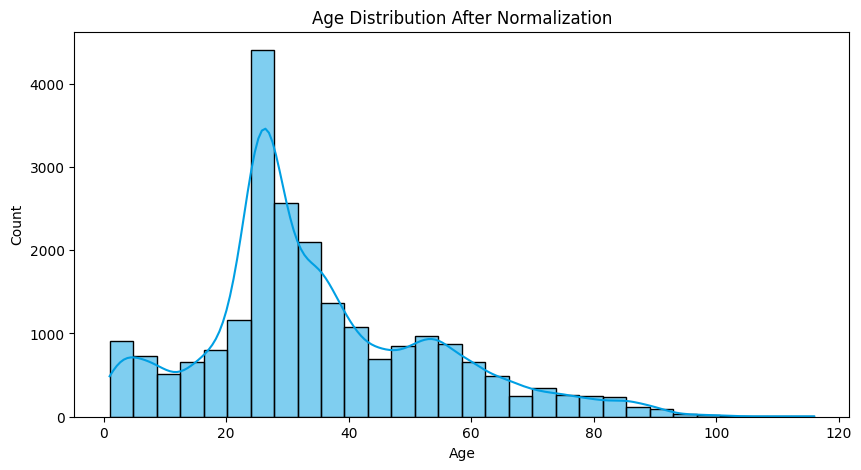

Total samples before balancing: 23708
Total samples after balancing: 22449
Train samples: 14367
Validation samples: 3592
Test samples: 4490


In [46]:
plt.figure(figsize=(10, 5))
sns.histplot(df_balanced['age'], bins=30, kde=True, color='#009FE3')
plt.title('Age Distribution After Normalization')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('age_distribution.png')
plt.show()

print(f"Total samples before balancing: {len(df)}")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

In [47]:
IMG_SIZE = 200
BATCH_SIZE = 32

In [48]:
def load_and_preprocess_image(path, age):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.keras.applications.mobilenet.preprocess_input(image)
    return image, tf.cast(age, tf.float32)

def create_dataset(df, batch_size=32, is_train=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['age'].values))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if is_train:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [49]:
train_dataset = create_dataset(train_df, BATCH_SIZE, is_train=True)
val_dataset = create_dataset(val_df, BATCH_SIZE, is_train=False)
test_dataset = create_dataset(test_df, BATCH_SIZE, is_train=False)

In [50]:
base_model = MobileNet(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='linear')(x)
model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error', metrics=['mae'])
model.summary()

/tmp/ipykernel_1970/227049358.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 100, 100, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 100, 100, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 100, 100, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 101, 101, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 50, 50, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 50, 50, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 50, 50, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 50, 50, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,193 (12.82 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [51]:
checkpoint_path = "model_checkpoint.keras"
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

In [52]:
if os.path.exists(checkpoint_path):
    print("Loading weights from previous checkpoint...")
    model.load_weights(checkpoint_path)

Loading weights from previous checkpoint...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [53]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[checkpoint_callback]
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 9.8982 - mae: 9.8982
Epoch 1: val_loss improved from None to 8.44054, saving model to model_checkpoint.keras

Epoch 1: finished saving model to model_checkpoint.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - loss: 9.7873 - mae: 9.7873 - val_loss: 8.4405 - val_mae: 8.4405
Epoch 2/30
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.2363 - mae: 9.2363
Epoch 2: val_loss improved from 8.44054 to 8.18476, saving model to model_checkpoint.keras

Epoch 2: finished saving model to model_checkpoint.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 9.2992 - mae: 9.2992 - val_loss: 8.1848 - val_mae: 8.1848
Epoch 3/30
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.1664 - mae: 9.1664
Epoch 3: val_loss improved from 8.18476 to 8.09850, saving model to model_checkpoint.keras

Epoch 3: finished saving model to model_checkpoint.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 9.1899 - mae: 9.1899 - val_loss: 8.0985 -

In [54]:
base_model.trainable = True

model.compile(optimizer=Adam(learning_rate=3e-5), loss='mean_absolute_error', metrics=['mae'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 100, 100, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 100, 100, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 100, 100, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 101, 101, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 50, 50, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 50, 50, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 50, 50, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 50, 50, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,193 (12.82 MB)

 Trainable params: 3,338,305 (12.73 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [55]:
checkpoint_path_ft = "model_checkpoint_ft.keras"
checkpoint_callback_ft = ModelCheckpoint(
    filepath=checkpoint_path_ft,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

print("Starting Fine-Tuning Phase...")
history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[checkpoint_callback_ft]
)

Starting Fine-Tuning Phase...
Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 13.3509 - mae: 13.3509
Epoch 1: val_loss improved from None to 11.39235, saving model to model_checkpoint_ft.keras

Epoch 1: finished saving model to model_checkpoint_ft.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 93s 136ms/step - loss: 12.0427 - mae: 12.0427 - val_loss: 11.3924 - val_mae: 11.3924
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 9.4850 - mae: 9.4850
Epoch 2: val_loss improved from 11.39235 to 8.61839, saving model to model_checkpoint_ft.keras

Epoch 2: finished saving model to model_checkpoint_ft.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - loss: 9.2525 - mae: 9.2525 - val_loss: 8.6184 - val_mae: 8.6184
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 8.0643 - mae: 8.0643
Epoch 3: val_loss improved from 8.61839 to 8.15972, saving model to model_checkpoint_ft.keras

Epoch 3: finished saving model to model_checkpoint_ft.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 8

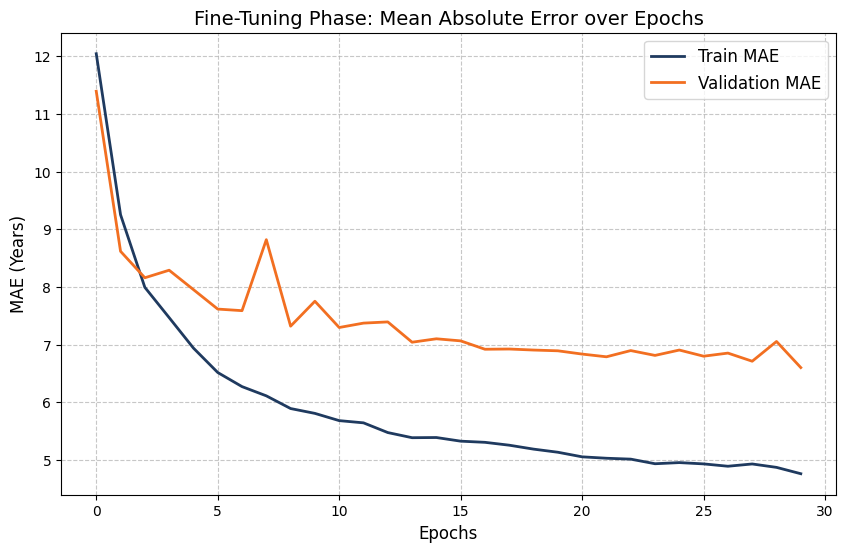

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(history_ft.history['mae'], label='Train MAE', color='#1F3A5F', linewidth=2)
plt.plot(history_ft.history['val_mae'], label='Validation MAE', color='#F26F21', linewidth=2)
plt.title('Fine-Tuning Phase: Mean Absolute Error over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE (Years)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('finetuning_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
model.load_weights(checkpoint_path_ft)

print("Evaluating on Test Dataset...")
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Final Test MAE: {test_mae:.2f} Years")

Evaluating on Test Dataset...
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 6.6561 - mae: 6.6561
Final Test MAE: 6.66 Years


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


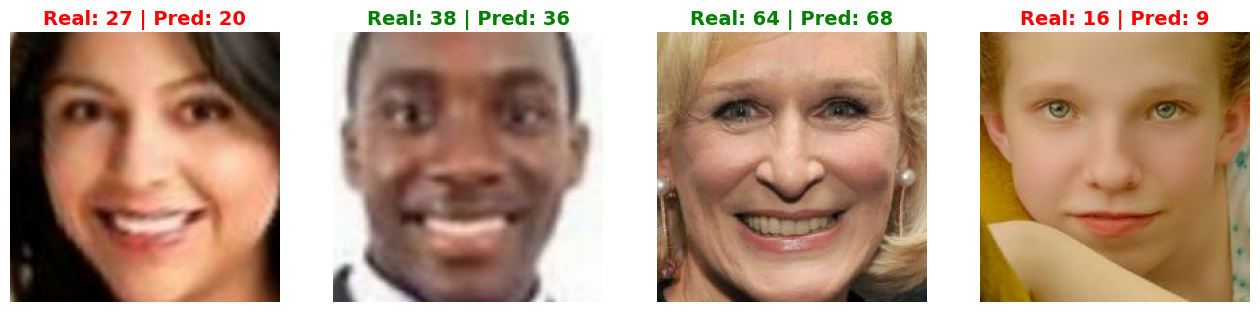

In [58]:
for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    plt.figure(figsize=(16, 5))
    for i in range(4):
        ax = plt.subplot(1, 4, i + 1)

        img = (images[i].numpy() + 1.0) / 2.0
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        real_age = int(labels[i].numpy())
        pred_age = int(preds[i][0])

        color = 'green' if abs(real_age - pred_age) <= 5 else 'red'

        plt.title(f"Real: {real_age} | Pred: {pred_age}", color=color, fontsize=14, fontweight='bold')
        plt.axis("off")

    plt.savefig('inference_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    break